In [17]:
from pathlib import Path
import spikeinterface.full as si

analyzer_folder = Path(r"F:\Data_Mice_IBL\VF074test\2026_03_24\sorting_analyzer\probe00")
analyzer = si.load_sorting_analyzer(analyzer_folder)

needed_extensions = [
    "unit_locations",
]

for ext in needed_extensions:
    if analyzer.get_extension(ext) is None:
        print(f"Compute extension: {ext}")
        analyzer.compute(ext, progress_bar=True)
    else:
        print(f"Extension déjà présente: {ext}")

Compute extension: unit_locations


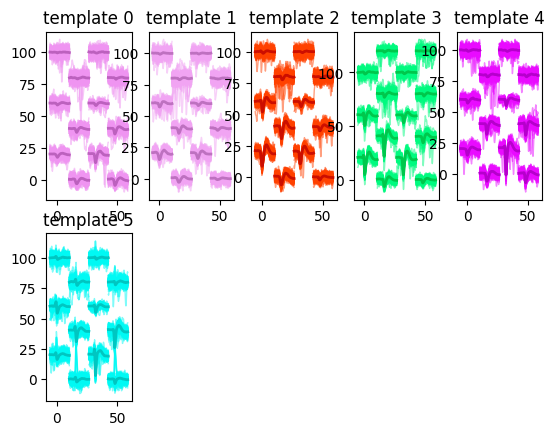

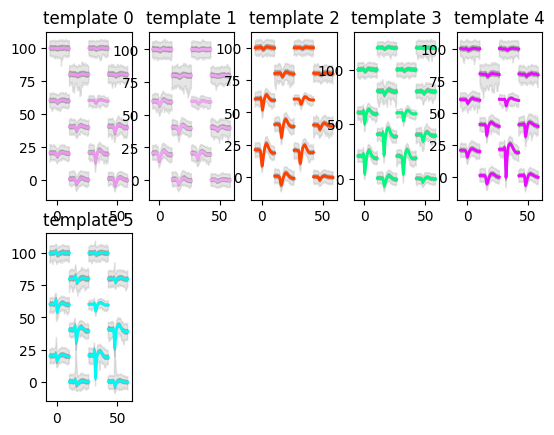

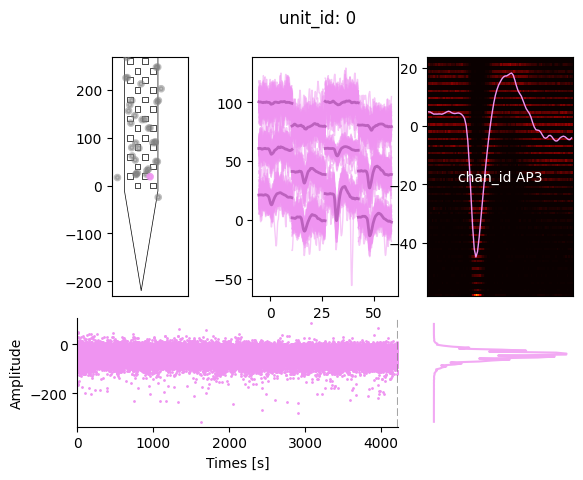

In [18]:
from pathlib import Path
import spikeinterface.full as si
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt

analyzer_folder = Path(r"F:\Data_Mice_IBL\VF074test\2026_03_24\sorting_analyzer\probe00")
analyzer = si.load_sorting_analyzer(analyzer_folder)

unit_ids_to_plot = list(analyzer.unit_ids)[:6]

# waveforms
sw.plot_unit_waveforms(
    analyzer,
    unit_ids=unit_ids_to_plot,
    max_spikes_per_unit=100,
)
plt.show()

# templates
sw.plot_unit_templates(
    analyzer,
    unit_ids=unit_ids_to_plot,
)
plt.show()

# summary complet d'une unité
unit_id = unit_ids_to_plot[0]
sw.plot_unit_summary(analyzer, unit_id=unit_id)
plt.show()

In [19]:
import numpy as np
from pathlib import Path

path = Path(r"F:\Data_Mice_IBL\VF074test\2026_03_24\sorting_analyzer\probe00\extensions\spike_amplitudes\amplitudes.npy")

amps = np.load(path)

print(type(amps))
print(amps.shape)
print(amps[:20])

<class 'numpy.ndarray'>
(13358039,)
[ -53.90625   56.25    -157.03125  -28.125    -37.5      -53.90625
  -75.       -49.21875 -140.625   -107.8125   -56.25     -25.78125
 -147.65625  -18.75     -70.3125   -58.59375  -25.78125  -46.875
  -53.90625 -206.25   ]


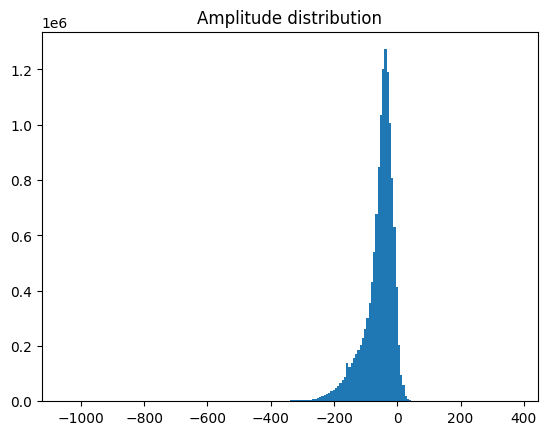

In [20]:
import matplotlib.pyplot as plt

plt.hist(amps, bins=200)
plt.title("Amplitude distribution")
plt.show()